In [6]:
import time
import numpy as np
import pandas as pd
import bottleneck as bn
from tqdm import tqdm
from astropy.time import Time
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord





def horizons_query(mjd, source="301", location="@hst"):
    # ----------------------------- #
    # ROLO lunar model
    # https://iopscience.iop.org/article/10.1086/430185/pdf
    # Moon id - 301
    # From HST - location = @hst
    # ----------------------------- #
    from astroquery.jplhorizons import Horizons

    jpl_horizons_query = Horizons(id=source, location=location, epochs=np.array(mjd) + 2400000.5)
    #print("Epochs:")
    #print(np.array(mjd) + 2400000.5)

    tolerance_time = 1/60./60.
    residual_time = tolerance_time + 1

    while np.abs(np.nanmax(residual_time))>tolerance_time: # If there is a mismatch higher than 1 sec, repeat.
        try:
            ephemeris_source_from_location = jpl_horizons_query.ephemerides()
        except Exception as error:
            # Handle the exception
            print("An exception occurred:", error) # An exception occurred: division by zero
            dummy = np.array([np.nan]*len(mjd))
            return({"RA": dummy, "DEC": dummy, "V": dummy, "datetime_jd": dummy})

        # RA_moon[i] = bn.nanmedian(moon_from_hst["RA"])
        # DEC_moon[i] = bn.nanmedian(moon_from_hst["DEC"])
        #print(ephemeris_source_from_location)
        RA_source = ephemeris_source_from_location["RA"].value.data
        DEC_source = ephemeris_source_from_location["DEC"].value.data
        V_source = ephemeris_source_from_location["V"].value.data
        datetime_jd = ephemeris_source_from_location["datetime_jd"].value.data
        residual_time = datetime_jd - np.array(mjd) - 2400000.5

        #print(residual_time)

        if np.abs(np.nanmax(residual_time))>tolerance_time:
            print("\nPotential mismatch in input/output MJD.")
            print("Epoch intro = " + str(np.array(mjd) + 2400000.5))
            print("Epoch output = " + str(np.array(datetime_jd)))
            print("Delta time = " + str(residual_time))
            print("Sleeping for 5 seconds...")
            time.sleep(5)

    return({"RA": RA_source, "DEC": DEC_source, "V": V_source, "datetime_jd": datetime_jd, "jpl_horizons_query": jpl_horizons_query})



In [7]:
horizons_query_db = horizons_query(mjd=60802, source="@jwst", location="@sun")

In [35]:
mjd = np.linspace(60300, 60802, 50)
from tqdm import tqdm 

x = np.zeros(mjd.shape)
y = np.zeros(mjd.shape)
z = np.zeros(mjd.shape)


for i in tqdm(range(len(mjd))):
    mjd_i = mjd[i]
    horizons_query_db = horizons_query(mjd=mjd_i, source="@jwst", location="@earth")
    vectors = horizons_query_db["jpl_horizons_query"].vectors()
    x[i] = vectors["x"]
    y[i] = vectors["y"]
    z[i] = vectors["z"]
    

  0%|                                                                                                                                                       | 0/50 [00:00<?, ?it/s]

An exception occurred: Ambiguous target name; provide unique id:
  ID#      Name                               Designation  IAU/aliases/other   
  -------  ---------------------------------- -----------  ------------------- 
        3  Earth-Moon Barycenter                           EMB                  
      399  Earth                                           Geocenter            
 


TypeError: object of type 'numpy.float64' has no len()

In [12]:
vectors = horizons_query_db["jpl_horizons_query"].vectors()


-0.6992214701984792


In [52]:
mjd = np.linspace(60000, 62802, 50)
db = horizons_query(mjd=mjd[0], source="@jwst", location="301")

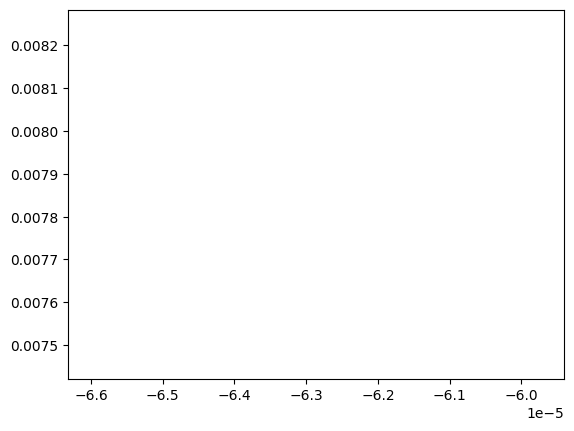

In [53]:
vectors = db["jpl_horizons_query"].vectors()

plt.plot(vectors["z"], vectors["y"])

In [60]:
np.array(vectors["x"].to("km"))

array([-877233.22492607])